In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('Ecommerce Customers')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [4]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


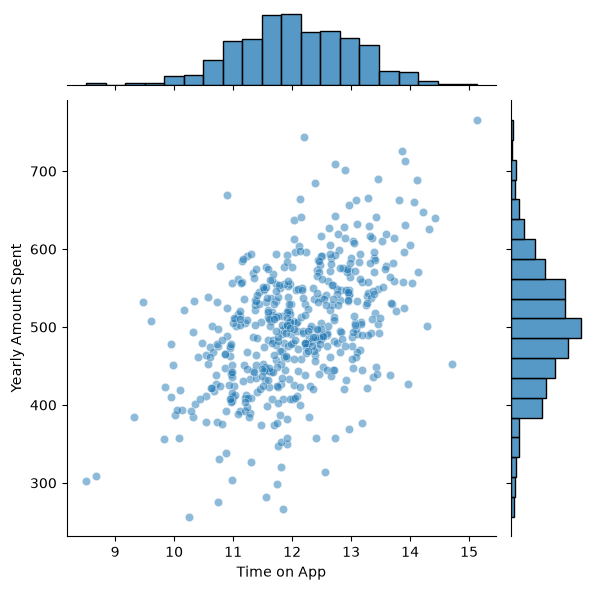

In [6]:
sns.jointplot(x="Time on App", y="Yearly Amount Spent", data=df, alpha=0.5)

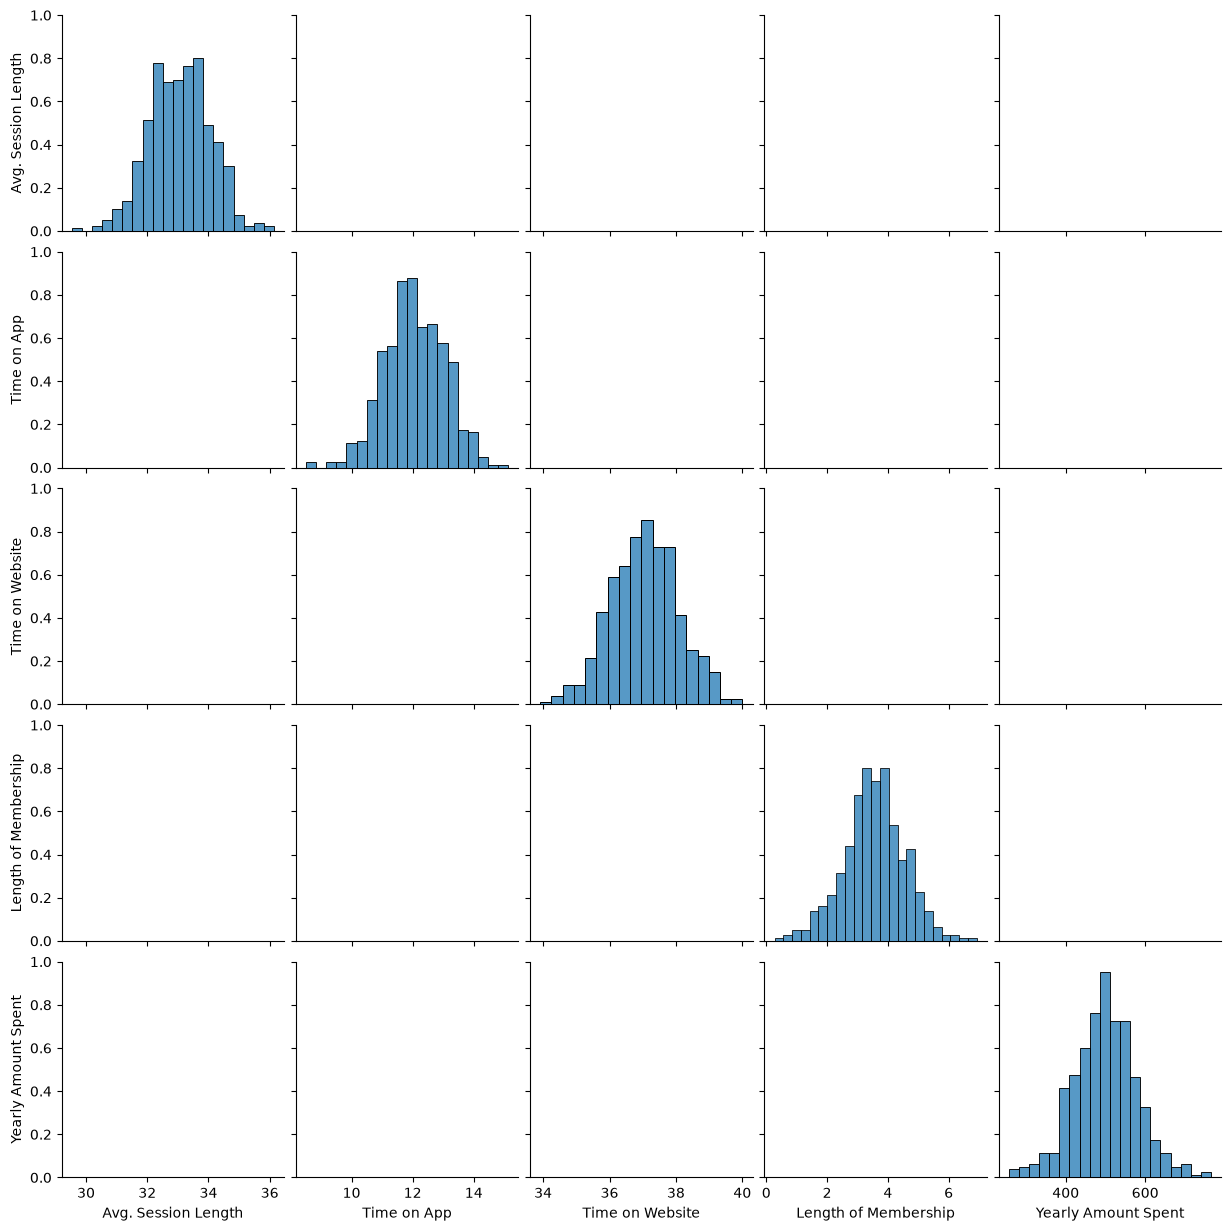

In [8]:
sns.pairplot(df, kind="sector", plot_kws={'alpha': 0.4})

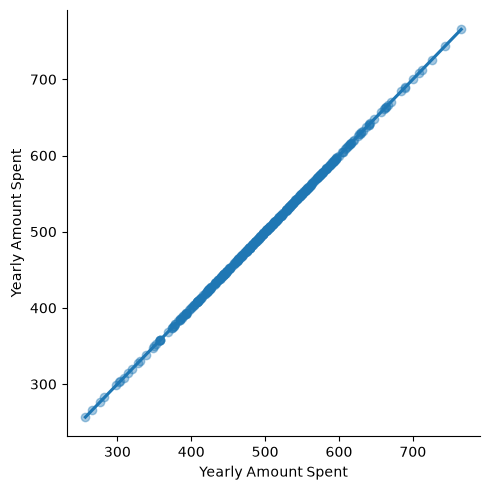

In [10]:
sns.lmplot(x="Yearly Amount Spent", y='Yearly Amount Spent', data=df, scatter_kws={'alpha': 0.4})

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='str')

In [17]:
X = df[['Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership']]
y = df['Yearly Amount Spent']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
lm  = LinearRegression()

In [22]:
lm.fit(X_train, y_train)

LinearRegression()

In [23]:
lm.coef_

array([25.72425621, 38.59713548,  0.45914788, 61.67473243])

In [25]:
cdf = pd.DataFrame(lm.coef_, X.columns , columns=['Coef'])
cdf

,Coef
Avg. Session Length,25.724256
Time on App,38.597135
Time on Website,0.459148
Length of Membership,61.674732


In [26]:
prediction = lm.predict(X_test)

In [27]:
prediction

array([403.66993069, 542.57756289, 427.06591658, 502.02460425,
       410.12143559, 569.93442508, 531.93431341, 506.29650969,
       408.71870658, 473.97737105, 441.46912726, 425.33703059,
       425.1297229 , 527.61676714, 431.45684016, 424.0769184 ,
       575.76543296, 484.89856554, 458.35936863, 481.96502182,
       502.32441491, 513.63783554, 507.58877002, 646.57464283,
       450.24372141, 496.27043415, 556.40457807, 554.95630839,
       399.64237199, 325.84623136, 532.89783259, 478.12238702,
       501.05701845, 305.97335848, 505.77244448, 483.79591969,
       518.8331528 , 438.18241857, 456.71094234, 471.04609461,
       494.44008972, 445.31155755, 508.78802753, 501.04594193,
       488.83499673, 535.38079541, 595.20129802, 514.04714872,
       280.76758312, 433.10112367, 421.70823427, 481.23640152,
       584.71372272, 608.7748096 , 563.98513427, 494.72804869,
       394.52133407, 456.4197529 , 573.08767515, 499.6984241 ,
       512.83277025, 392.12434043, 480.05057697, 481.54

Text(0.5, 1.0, 'Evelution of our LM model')

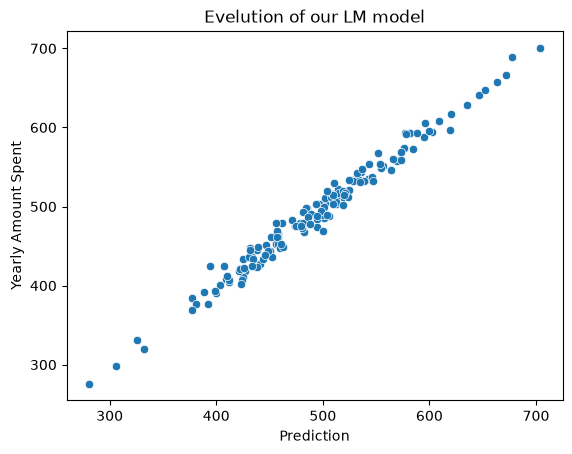

In [30]:
from matplotlib import pyplot as plt


sns.scatterplot(x=prediction, y=y_test)
plt.xlabel("Prediction")
plt.title("Evelution of our LM model")

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

In [33]:
print('mean_absolute_error', mean_absolute_error(y_test, prediction))
print('mean_squired_error', mean_squared_error(y_test, prediction))
print('RSME: ', math.sqrt(mean_squared_error(y_test, prediction)))

mean_absolute_error 8.4260916414321
mean_squired_error 103.91554136503325
RSME:  10.193897260863151


In [34]:
residuals = y_test - prediction

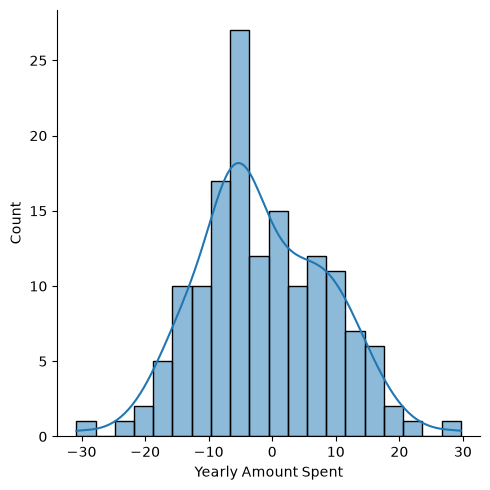

In [37]:
sns.displot(residuals, bins=20, kde=True)